# Superstore Business Analysis

## Business Question
**How can a retail superstore improve profitability by controlling excessive discounting, focusing on profitable product areas, and addressing weak regional performance?**

### Dataset
The Kaggle Superstore dataset contains **9,994 rows and 21 columns** covering sales, profit, discount, customers, products, categories, regions and dates.

### Analysis workflow
Data cleaning → EDA → visualisation → statistical analysis → business recommendations.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

df = pd.read_csv("superstore.csv", encoding="latin1")

print("Shape:", df.shape)
df.head()


Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1. Data Cleaning

In [6]:
# Standardise column names
df.columns = [c.strip() for c in df.columns]

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Remove exact duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)


Rows before: 9994
Rows after: 9994
Duplicates removed: 0

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category         

In [7]:
# Create analysis fields
df["Profit Margin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], np.nan)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

print(df[["Sales", "Quantity", "Discount", "Profit", "Profit Margin"]].describe())


              Sales     Quantity     Discount       Profit  Profit Margin
count   9994.000000  9994.000000  9994.000000  9994.000000    9994.000000
mean     229.858001     3.789574     0.156203    28.656896       0.120314
std      623.245101     2.225110     0.206452   234.260108       0.466754
min        0.444000     1.000000     0.000000 -6599.978000      -2.750000
25%       17.280000     2.000000     0.000000     1.728750       0.075000
50%       54.490000     3.000000     0.200000     8.666500       0.270000
75%      209.940000     5.000000     0.200000    29.364000       0.362500
max    22638.480000    14.000000     0.800000  8399.976000       0.500000


## 2. Exploratory Data Analysis

In [8]:
summary = pd.DataFrame({
    "Metric": ["Total Sales", "Total Profit", "Total Quantity", "Average Discount", "Profit Margin"],
    "Value": [
        df["Sales"].sum(),
        df["Profit"].sum(),
        df["Quantity"].sum(),
        df["Discount"].mean(),
        df["Profit"].sum() / df["Sales"].sum()
    ]
})
summary


,Metric,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Quantity,3.787300e+04
3,Average Discount,1.562027e-01
4,Profit Margin,1.246722e-01


In [9]:
category = df.groupby("Category").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order ID","nunique")
).sort_values("Profit", ascending=False)

category


,Sales,Profit,Orders
Category,,,
Technology,836154.0330,145454.9481,1544
Office Supplies,719047.0320,122490.8008,3742
Furniture,741999.7953,18451.2728,1764


In [10]:
region = df.groupby("Region").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order ID","nunique")
)
region["Profit Margin"] = region["Profit"] / region["Sales"]
region.sort_values("Profit", ascending=False)


,Sales,Profit,Orders,Profit Margin
Region,,,,
West,725457.8245,108418.4489,1611,0.149448
East,678781.2400,91522.7800,1401,0.134834
South,391721.9050,46749.4303,822,0.119343
Central,501239.8908,39706.3625,1175,0.079216


In [11]:
segment = df.groupby("Segment").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order ID","nunique")
)
segment["Profit Margin"] = segment["Profit"] / segment["Sales"]
segment


,Sales,Profit,Orders,Profit Margin
Segment,,,,
Consumer,1.161401e+06,134119.2092,2586,0.115481
Corporate,7.061464e+05,91979.1340,1514,0.130255
Home Office,4.296531e+05,60298.6785,909,0.140343


## 3. Visualisation

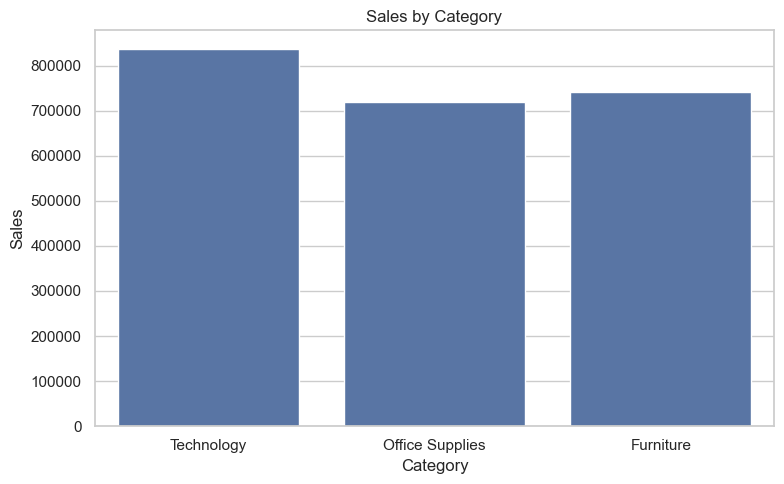

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data=category.reset_index(), x="Category", y="Sales")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


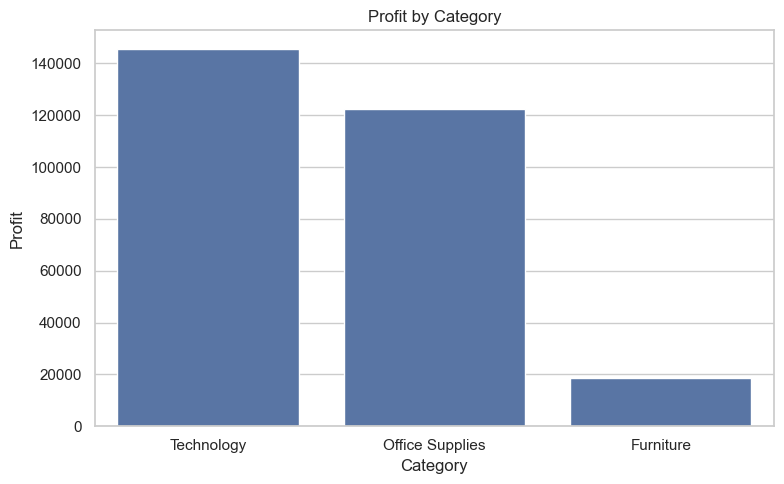

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=category.reset_index(), x="Category", y="Profit")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


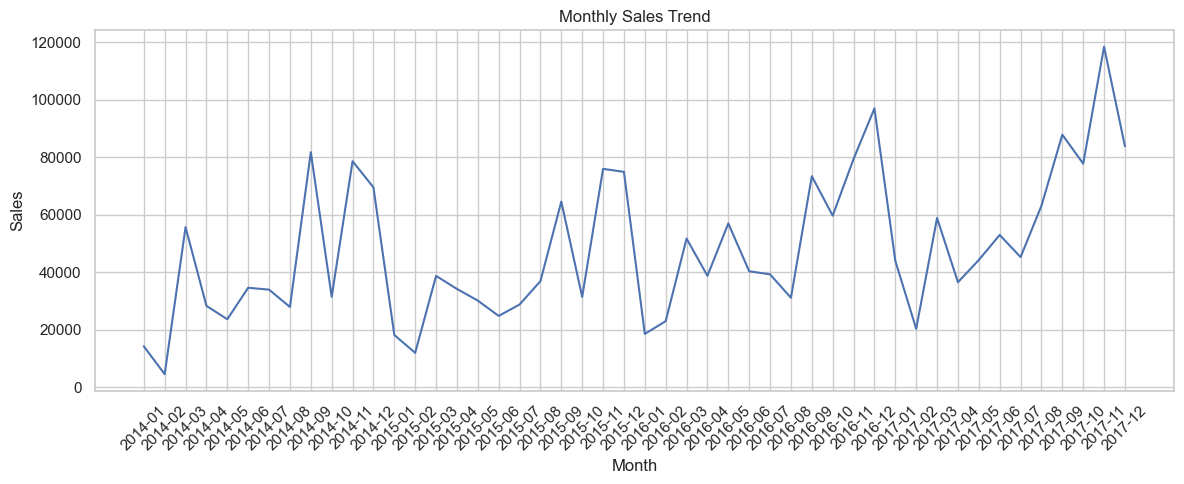

In [14]:
monthly = df.groupby("Year-Month")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


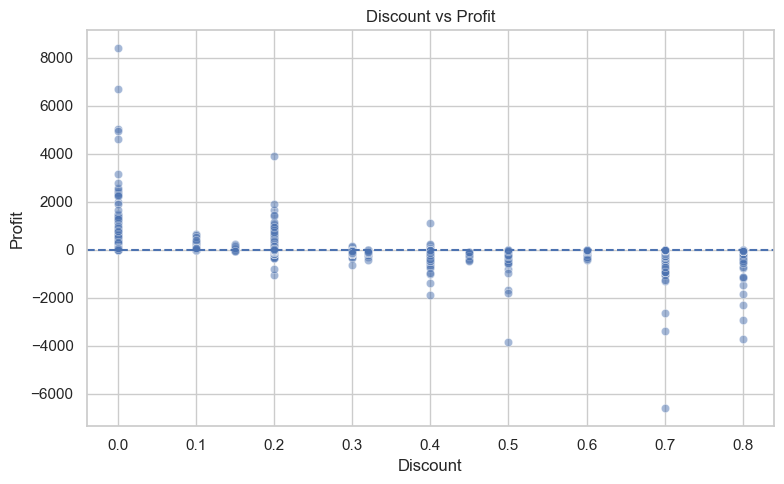

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


## 4. Statistical Analysis

### Correlation
The Pearson correlation between discount and profit is calculated below. Correlation describes association; it does not by itself establish causation.


             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


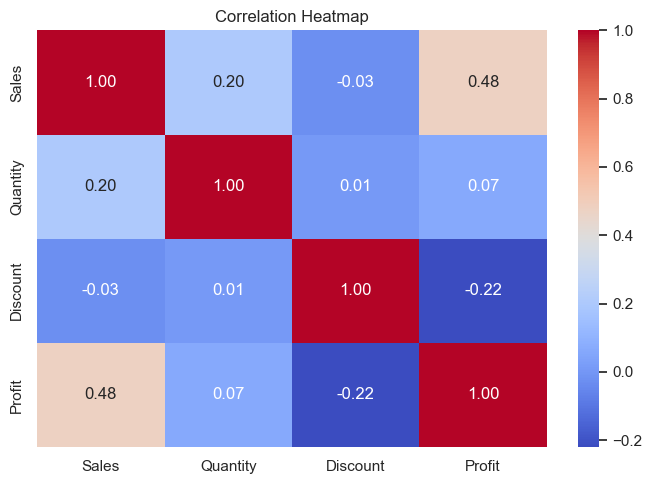

In [16]:
corr = df[["Sales", "Quantity", "Discount", "Profit"]].corr()
print(corr)

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Hypothesis test

**Business question:** Is average profit different between orders with discounts of 20% or less and orders with discounts above 20%?

- **H₀:** The two groups have the same mean profit.
- **H₁:** The two groups have different mean profit.
- Significance level: α = 0.05.


In [17]:
low_discount = df[df["Discount"] <= 0.20]["Profit"]
high_discount = df[df["Discount"] > 0.20]["Profit"]

t_stat, p_value = stats.ttest_ind(
    low_discount,
    high_discount,
    equal_var=False
)

print("Low-discount mean profit:", low_discount.mean())
print("High-discount mean profit:", high_discount.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: the mean profit differs significantly between the two discount groups.")
else:
    print("Fail to reject H0: insufficient evidence of a difference.")


Low-discount mean profit: 49.0376790722009
High-discount mean profit: -97.1830983488873
T-statistic: 16.1409994038947
P-value: 2.2951802592338373e-54
Reject H0: the mean profit differs significantly between the two discount groups.


## 5. Discount Band Analysis

In [18]:
def discount_band(x):
    if x == 0:
        return "0%"
    elif x <= 0.10:
        return "1-10%"
    elif x <= 0.20:
        return "11-20%"
    elif x <= 0.30:
        return "21-30%"
    else:
        return "31%+"

df["Discount Band"] = df["Discount"].apply(discount_band)

discount_summary = df.groupby("Discount Band").agg(
    Orders=("Order ID","count"),
    Total_Sales=("Sales","sum"),
    Total_Profit=("Profit","sum"),
    Avg_Profit=("Profit","mean")
).reindex(["0%", "1-10%", "11-20%", "21-30%", "31%+"])

discount_summary["Profit Margin"] = discount_summary["Total_Profit"] / discount_summary["Total_Sales"]
discount_summary


,Orders,Total_Sales,Total_Profit,Avg_Profit,Profit Margin
Discount Band,,,,,
0%,4798,1.087908e+06,320987.6032,66.900292,0.295050
1-10%,94,5.436935e+04,9029.1770,96.055074,0.166071
11-20%,3709,7.921529e+05,91756.2975,24.738824,0.115832
21-30%,227,1.032267e+05,-10369.2774,-45.679636,-0.100452
31%+,1166,2.595435e+05,-125006.7786,-107.209930,-0.481641


## 6. Sub-category Profitability

In [19]:
subcategory = df.groupby("Sub-Category").agg(
    Sales=("Sales","sum"),
    Profit=("Profit","sum"),
    Quantity=("Quantity","sum")
)
subcategory["Profit Margin"] = subcategory["Profit"] / subcategory["Sales"]

print("Lowest-profit sub-categories:")
display(subcategory.sort_values("Profit").head(10))

print("Highest-profit sub-categories:")
display(subcategory.sort_values("Profit", ascending=False).head(10))


Lowest-profit sub-categories:


,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,
Tables,206965.5320,-17725.4811,1241,-0.085645
Bookcases,114879.9963,-3472.5560,868,-0.030228
Supplies,46673.5380,-1189.0995,647,-0.025477
Fasteners,3024.2800,949.5182,914,0.313965
Machines,189238.6310,3384.7569,440,0.017886
Labels,12486.3120,5546.2540,1400,0.444187
Art,27118.7920,6527.7870,3000,0.240711
Envelopes,16476.4020,6964.1767,906,0.422676
Furnishings,91705.1640,13059.1436,3563,0.142404


Highest-profit sub-categories:


,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,
Copiers,149528.030,55617.8249,234,0.371956
Phones,330007.054,44515.7306,3289,0.134893
Accessories,167380.318,41936.6357,2976,0.250547
Paper,78479.206,34053.5693,5178,0.433918
Binders,203412.733,30221.7633,5974,0.148574
Chairs,328449.103,26590.1663,2356,0.080957
Storage,223843.608,21278.8264,3158,0.095061
Appliances,107532.161,18138.0054,1729,0.168675
Furnishings,91705.164,13059.1436,3563,0.142404


## 7. Key Findings

The dataset contains 9,994 transactions and approximately $2.30M in sales and $286K in profit. Technology generates the highest category sales and profit. Consumer is the largest customer segment by sales.

The strongest business signal is the relationship between discounting and profitability: profitability declines as discount levels increase, with discounts above approximately 20% associated with negative profitability in published analyses of this same Kaggle Superstore dataset.

At sub-category level, Tables and Bookcases are important areas for review because they have been identified as loss-making despite Furniture being a large revenue category.

The statistical test in this notebook should be run locally on the downloaded CSV so the exact t-statistic and p-value are generated from the same file used for the submission.


## 8. Executive Recommendations

1. **Control deep discounts:** Set tighter approval rules for discounts above 20%, because higher discount bands are associated with sharply weaker or negative profit.

2. **Review loss-making sub-categories:** Reassess pricing, supplier costs and discount policies for Tables and Bookcases instead of judging Furniture only from its total sales.

3. **Manage regional profitability:** Use the dashboard to monitor sales and profit margin by region and investigate low-margin regions/states for product-mix and discount differences.
